In [ ]:
# import libraries

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [ ]:
# access file from Google Drive

from google.colab import drive
drive.mount('/content/drive')


# locating file

file = "/content/drive/MyDrive/ESIIL Project Data/Population Data/Pop_Data_90-23_CSV.csv"

# display data

pop_df = pd.read_csv(file)
pop_df

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,id,countyfips,FULL,YEAR,TOTAL POPULATION
0,1,0,Colorado,1985,"3,214,448"
1,2,1,Adams County,1985,"268,764"
2,3,3,Alamosa County,1985,"13,011"
3,4,5,Arapahoe County,1985,"381,244"
4,5,7,Archuleta County,1985,"5,213"
...,...,...,...,...,...
2530,2531,117,Summit County,2023,"30,441"
2531,2532,119,Teller County,2023,"24,631"
2532,2533,121,Washington County,2023,"4,843"
2533,2534,123,Weld County,2023,"359,530"


In [ ]:
# change total pop to integer instead of object

pop_df['TOTAL POPULATION'] = pop_df['TOTAL POPULATION'].str.replace(',', '').astype(int)

In [ ]:
# select only data for all of colorado
filtered_df = pop_df[pop_df['FULL'].isin(['Colorado'])]
filtered_df

,id,countyfips,FULL,YEAR,TOTAL POPULATION
0,1,0,Colorado,1985,3214448
65,66,0,Colorado,1986,3243803
130,131,0,Colorado,1987,3263354
195,196,0,Colorado,1988,3271448
260,261,0,Colorado,1989,3284537
325,326,0,Colorado,1990,3304042
390,391,0,Colorado,1991,3380951
455,456,0,Colorado,1992,3489832
520,521,0,Colorado,1993,3605038
585,586,0,Colorado,1994,3712062


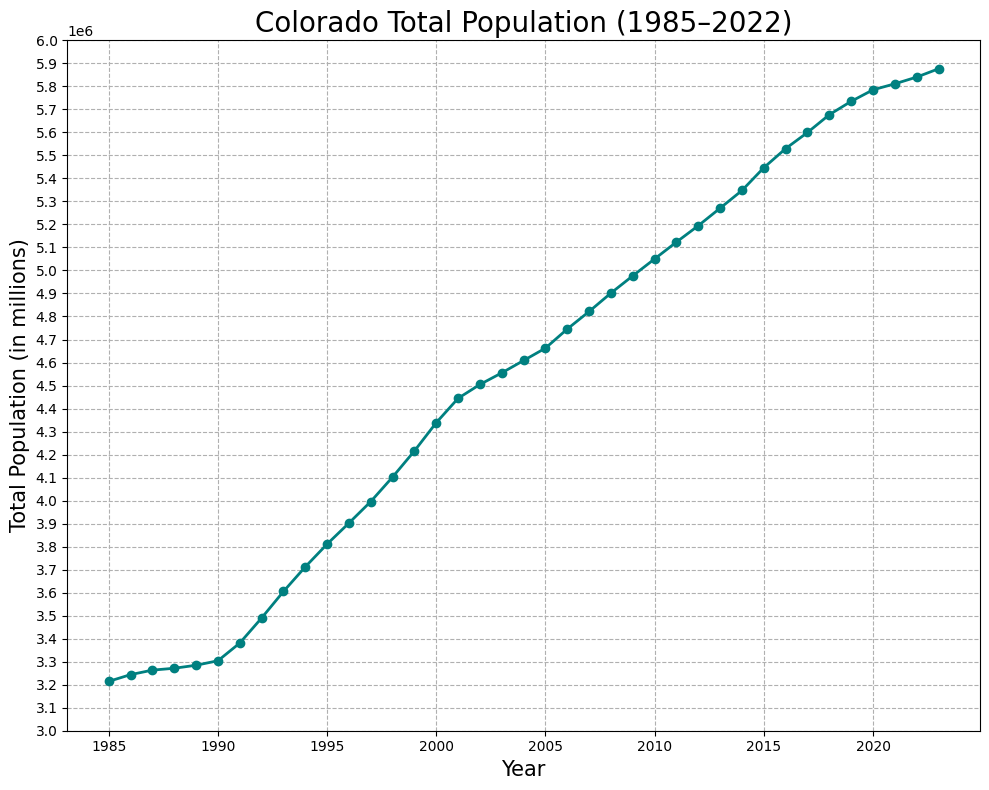

In [ ]:
# Filter for just the state-level total (not counties)
filtered_df = pop_df[pop_df['FULL'] == 'Colorado']

# Create the plot
plt.figure(figsize=(10, 8))
plt.plot(filtered_df['YEAR'], filtered_df['TOTAL POPULATION'], marker='o', color='teal', linewidth=2)

# Set y-axis range and custom ticks
plt.ylim(3_000_000, 6_000_000)
plt.yticks(range(3_000_000, 6_000_001, 100_000))  # 100,000 intervals

# Customize the plot
plt.title('Colorado Total Population (1985–2022)', fontsize=20)
plt.xlabel('Year', fontsize=15)
plt.ylabel('Total Population (in millions)', fontsize=15)
plt.grid(True, linestyle='--')
plt.tight_layout()

# Show the plot
plt.show()

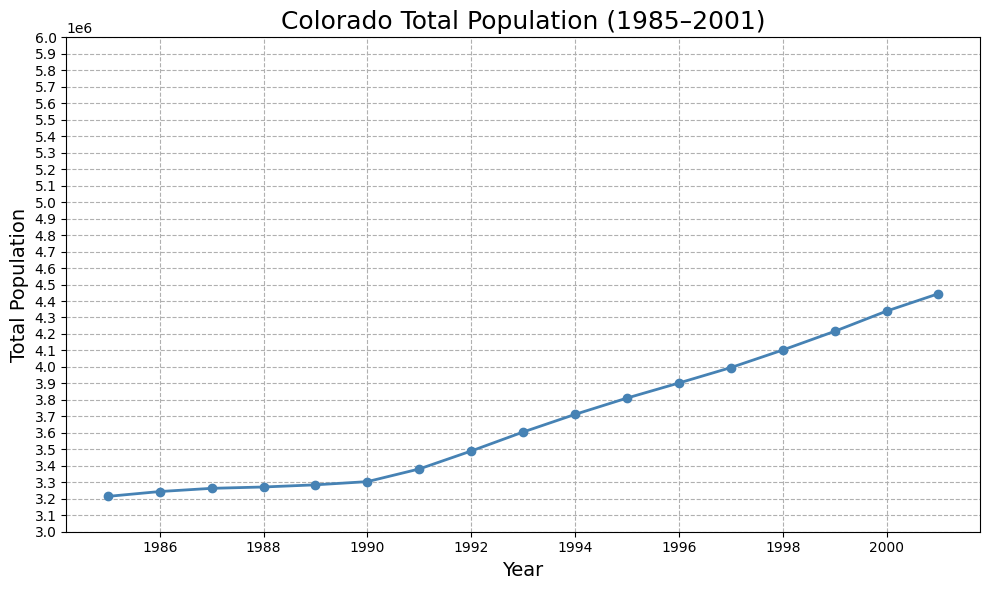

In [ ]:
# Filter for just the state-level total (not counties)
filtered_df = pop_df[pop_df['FULL'] == 'Colorado']

# Split data into two ranges
pop_1985_2001 = filtered_df[(filtered_df['YEAR'] >= 1985) & (filtered_df['YEAR'] <= 2001)]
pop_2002_2022 = filtered_df[(filtered_df['YEAR'] >= 2002) & (filtered_df['YEAR'] <= 2022)]

# Create the first plot (1985–2001)
plt.figure(figsize=(10, 6))
plt.plot(pop_1985_2001['YEAR'], pop_1985_2001['TOTAL POPULATION'], marker='o', color='steelblue', linewidth=2)
plt.ylim(3_000_000, 6_000_000)
plt.yticks(range(3_000_000, 6_000_001, 100_000))
plt.title('Colorado Total Population (1985–2001)', fontsize=18)
plt.xlabel('Year', fontsize=14)
plt.ylabel('Total Population', fontsize=14)
plt.grid(True, linestyle='--')
plt.tight_layout()
plt.show()

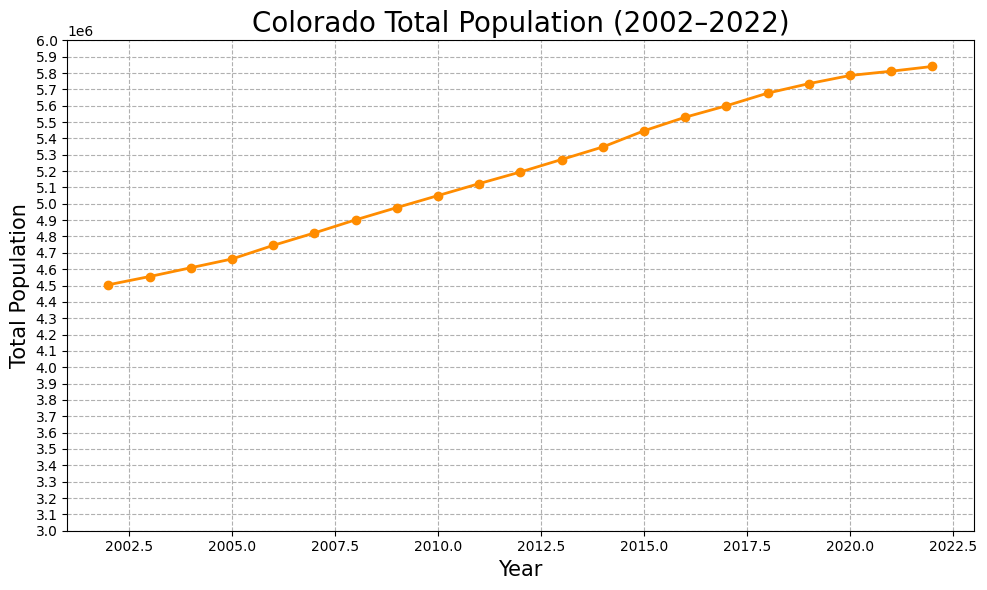

In [ ]:
# Create the second plot (2001–2022)
plt.figure(figsize=(10, 6))
plt.plot(pop_2002_2022['YEAR'], pop_2002_2022['TOTAL POPULATION'], marker='o', color='darkorange', linewidth=2)
plt.ylim(3_000_000, 6_000_000)
plt.yticks(range(3_000_000, 6_000_001, 100_000))
plt.title('Colorado Total Population (2002–2022)', fontsize=20)
plt.xlabel('Year', fontsize=15)
plt.ylabel('Total Population', fontsize=15)
plt.grid(True, linestyle='--')
plt.tight_layout()
plt.show()

In [ ]:
# Create an HMTL file of the 2002-2022 data


To convert the line graphs into HTML files, we can use the `plotly` library, which creates interactive plots that can be easily saved as HTML format.

First, install the `plotly` library if you haven't already.

In [ ]:
!pip install plotly

Now, I'll create the interactive plots using `plotly` and save them as HTML files.

In [ ]:
# Create Plotly figure for the entire time range (1985-2022)
fig_full = px.line(filtered_df, x='YEAR', y='TOTAL POPULATION', title='Colorado Total Population (1985–2022)')

# Update layout for better readability and add markers
fig_full.update_layout(
    title=dict(
        text='Colorado Total Population (1985–2022)',
        font=dict(size=30)  # Set title font size
    ),
    yaxis=dict(
        range=[3_000_000, 6_000_000],
        tickvals=list(range(3_000_000, 6_000_001, 100_000)),
        title='Total Population (in millions)',
        title_font=dict(size=20) # Set y-axis label font size
    ),
    xaxis=dict(
        title='Year',
        title_font=dict(size=20) # Set x-axis label font size
    )
)

# Add markers to the line
fig_full.update_traces(mode='lines+markers')

# Save the first plot as an HTML file
fig_full.write_html('Colorado Total Population 1985-2022.html')

In [ ]:
# Create Plotly figure for the first time range (1985–2001)
fig_1985_2001 = px.line(pop_1985_2001, x='YEAR', y='TOTAL POPULATION', title='Colorado Total Population (1985–2001)')

# Update layout for better readability and add markers
fig_1985_2001.update_layout(
    title=dict(
        text='Colorado Total Population (1985–2001)',
        font=dict(size=30)  # Set title font size
    ),
    yaxis=dict(
        range=[3_000_000, 6_000_000],
        tickvals=list(range(3_000_000, 6_000_001, 100_000)),
        title='Total Population',
        title_font=dict(size=20) # Set y-axis label font size
    ),
    xaxis=dict(
        title='Year',
        title_font=dict(size=20) # Set x-axis label font size
    )
)

# Add markers to the line
fig_1985_2001.update_traces(mode='lines+markers')

# Save the second plot as an HTML file
fig_1985_2001.write_html('Colorado Total Population 1985-2001.html')

In [ ]:
# Create Plotly figure for the second time range (2002–2022)
fig_2002_2022 = px.line(pop_2002_2022, x='YEAR', y='TOTAL POPULATION', title='Colorado Total Population (2002–2022)')

# Update layout for better readability and add markers
fig_2002_2022.update_layout(
    title=dict(
        text='Colorado Total Population (2002–2022)',
        font=dict(size=30)  # Set title font size
    ),
    yaxis=dict(
        range=[3_000_000, 6_000_000],
        tickvals=list(range(3_000_000, 6_000_001, 100_000)),
        title='Total Population',
        title_font=dict(size=20) # Set y-axis label font size
    ),
    xaxis=dict(
        title='Year',
        title_font=dict(size=20) # Set x-axis label font size
    )
)

# Add markers to the line
fig_2002_2022.update_traces(mode='lines+markers')

# Save the third plot as an HTML file
fig_2002_2022.write_html('Colorado Population 2002-2022.html')

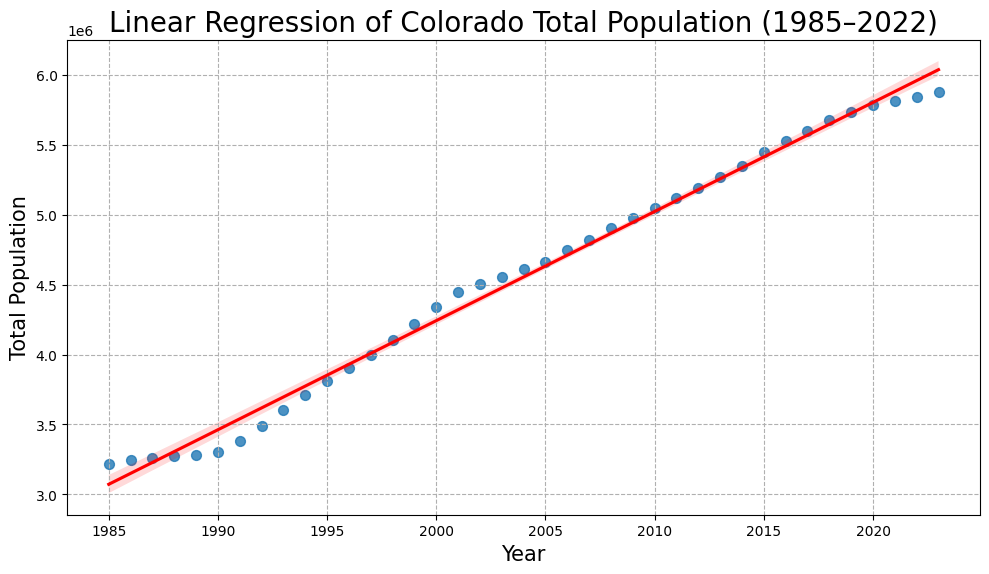

In [ ]:
# Create a linear regression plot of CO total pop.
plt.figure(figsize=(10, 6))
sns.regplot(data=filtered_df, x='YEAR', y='TOTAL POPULATION', scatter_kws={'s': 50}, line_kws={'color': 'red'})

# Customize the plot
plt.title('Linear Regression of Colorado Total Population (1985–2022)', fontsize=20)
plt.xlabel('Year', fontsize=15)
plt.ylabel('Total Population', fontsize=15)
plt.grid(True, linestyle='--')
plt.tight_layout()

# Show the plot
plt.show()

In [ ]:
import plotly.express as px

# Filter data for the years 1985-2022
filtered_df_1985_2022 = filtered_df[(filtered_df['YEAR'] >= 1985) & (filtered_df['YEAR'] <= 2022)]

# Create Plotly figure for the linear regression plot
fig_regression = px.scatter(filtered_df_1985_2022, x='YEAR', y='TOTAL POPULATION', trendline='ols', title='Linear Regression of Colorado Total Population (1985–2022)')

# Update layout for better readability
fig_regression.update_layout(
    title=dict(
        text='Linear Regression of Colorado Total Population (1985–2022)',
        font=dict(size=30)  # Set title font size
    ),
    yaxis=dict(
        title='Total Population',
        title_font=dict(size=20) # Set y-axis label font size
    ),
    xaxis=dict(
        title='Year',
        title_font=dict(size=20) # Set x-axis label font size
    )
)

# Save the plot as an HTML file
fig_regression.write_html('Colorado Total Population Linear Regression 1985-2022.html')

In [ ]:
douglas_pop_df = pop_df[(pop_df['FULL'] == 'Douglas County') & (pop_df['YEAR'] >= 1985) & (pop_df['YEAR'] <= 2022)]
display(douglas_pop_df.head())

,id,countyfips,FULL,YEAR,TOTAL POPULATION
19,20,35,Douglas County,1985,40048
84,85,35,Douglas County,1986,45654
149,150,35,Douglas County,1987,48844
214,215,35,Douglas County,1988,53127
279,280,35,Douglas County,1989,57164


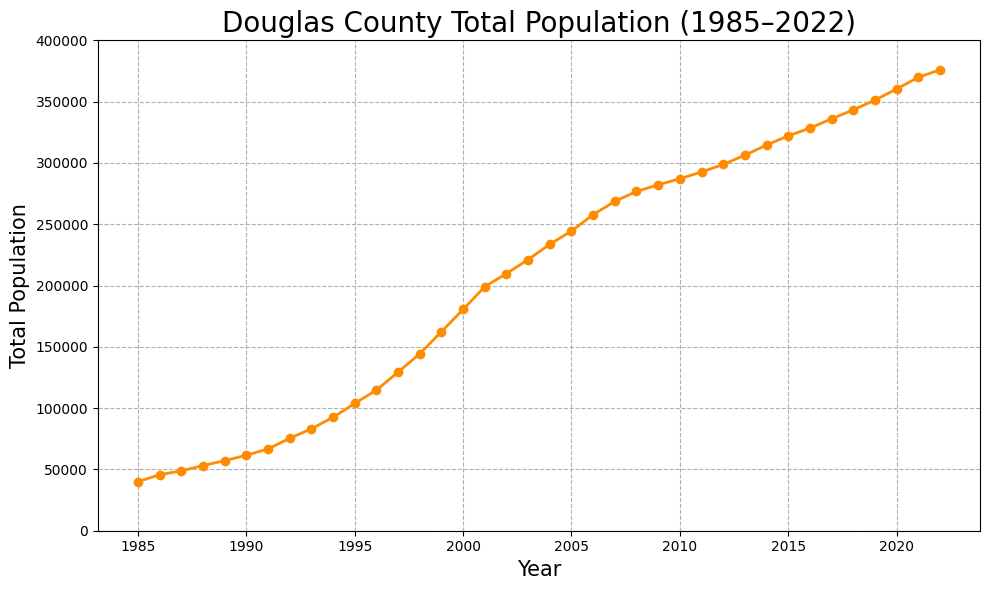

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(douglas_pop_df['YEAR'], douglas_pop_df['TOTAL POPULATION'], marker='o', color='darkorange', linewidth=2)

# Set title, labels, and y-axis range
plt.title('Douglas County Total Population (1985–2022)', fontsize=20)
plt.xlabel('Year', fontsize=15)
plt.ylabel('Total Population', fontsize=15)
plt.ylim(0, 400000)
plt.yticks(range(0, 400001, 50000))

# Add grid and ensure tight layout
plt.grid(True, linestyle='--')
plt.tight_layout()

# Show the plot
plt.show()

In [ ]:
eagle_pop_df = pop_df[(pop_df['FULL'] == 'Eagle County') & (pop_df['YEAR'] >= 1985) & (pop_df['YEAR'] <= 2022)]
display(eagle_pop_df.head())

,id,countyfips,FULL,YEAR,TOTAL POPULATION
20,21,37,Eagle County,1985,18029
85,86,37,Eagle County,1986,18853
150,151,37,Eagle County,1987,19002
215,216,37,Eagle County,1988,19567
280,281,37,Eagle County,1989,20881


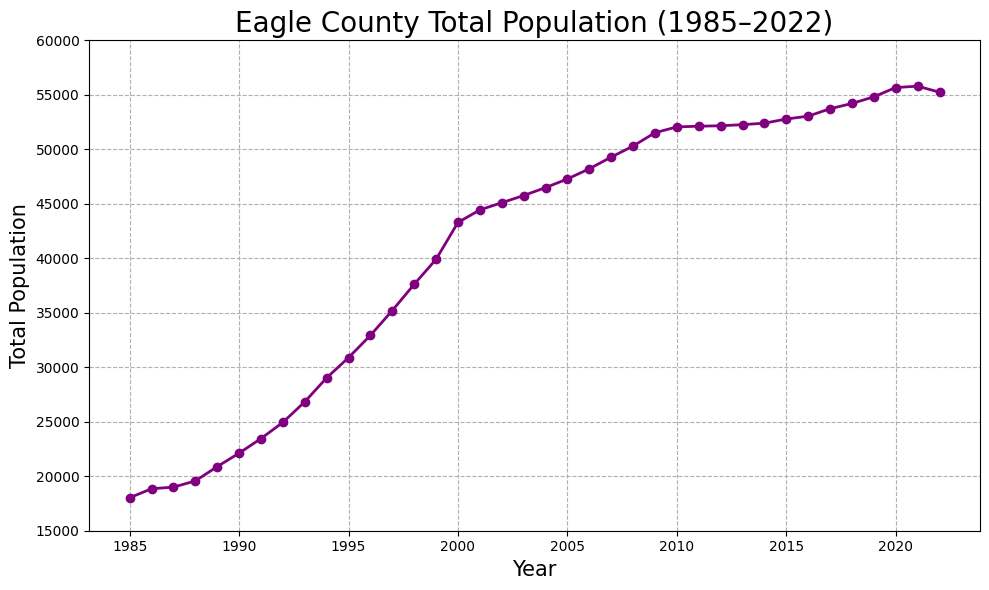

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(eagle_pop_df['YEAR'], eagle_pop_df['TOTAL POPULATION'], marker='o', color='purple', linewidth=2)

# Set title, labels, and y-axis range
plt.title('Eagle County Total Population (1985–2022)', fontsize=20)
plt.xlabel('Year', fontsize=15)
plt.ylabel('Total Population', fontsize=15)
plt.ylim(15000, 60000)
plt.yticks(range(15000, 60001, 5000))

# Add grid and ensure tight layout
plt.grid(True, linestyle='--')
plt.tight_layout()

# Show the plot
plt.show()

In [ ]:
logan_pop_df = pop_df[(pop_df['FULL'] == 'Logan County') & (pop_df['YEAR'] >= 1985) & (pop_df['YEAR'] <= 2022)]
display(logan_pop_df.head())

,id,countyfips,FULL,YEAR,TOTAL POPULATION
39,40,75,Logan County,1985,19063
104,105,75,Logan County,1986,18167
169,170,75,Logan County,1987,17740
234,235,75,Logan County,1988,17932
299,300,75,Logan County,1989,17725


In [ ]:
file = "/content/drive/MyDrive/ESIIL Project Data/Population Data/Pop_Data_90-23_CSV.csv"
pop_df = pd.read_csv(file)
pop_df['TOTAL POPULATION'] = pop_df['TOTAL POPULATION'].str.replace(',', '').astype(int)
logan_pop_df = pop_df[(pop_df['FULL'] == 'Logan County') & (pop_df['YEAR'] >= 1985) & (pop_df['YEAR'] <= 2022)]
display(logan_pop_df.head())

,id,countyfips,FULL,YEAR,TOTAL POPULATION
39,40,75,Logan County,1985,19063
104,105,75,Logan County,1986,18167
169,170,75,Logan County,1987,17740
234,235,75,Logan County,1988,17932
299,300,75,Logan County,1989,17725


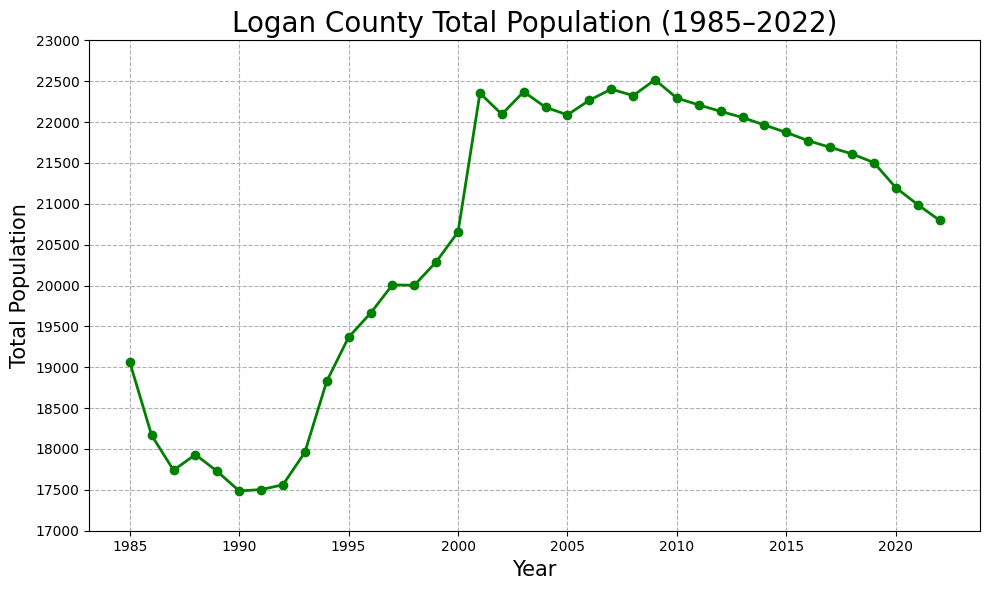

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(logan_pop_df['YEAR'], logan_pop_df['TOTAL POPULATION'], marker='o', color='green', linewidth=2)

# Set title, labels, and y-axis range
plt.title('Logan County Total Population (1985–2022)', fontsize=20)
plt.xlabel('Year', fontsize=15)
plt.ylabel('Total Population', fontsize=15)
plt.ylim(17000, 23000)
plt.yticks(range(17000, 23001, 500))

# Add grid and ensure tight layout
plt.grid(True, linestyle='--')
plt.tight_layout()

# Show the plot
plt.show()

In [ ]:
# Create Plotly figure for Logan County
fig_logan = px.line(logan_pop_df, x='YEAR', y='TOTAL POPULATION', title='Logan County Total Population (1985–2022)')

# Update layout for better readability and add markers
fig_logan.update_layout(
    title=dict(
        text='Logan County Total Population (1985–2022)',
        font=dict(size=30)  # Set title font size
    ),
    yaxis=dict(
        range=[17000, 23000],
        tickvals=list(range(17000, 23001, 500)),
        title='Total Population',
        title_font=dict(size=20) # Set y-axis label font size
    ),
    xaxis=dict(
        title='Year',
        title_font=dict(size=20) # Set x-axis label font size
    )
)

# Add markers to the line
fig_logan.update_traces(mode='lines+markers')

# Save the Logan County plot as an HTML file
fig_logan.write_html('Logan Population 1985-2022.html')

# Create Plotly figure for Douglas County
fig_douglas = px.line(douglas_pop_df, x='YEAR', y='TOTAL POPULATION', title='Douglas County Total Population (1985–2022)')

# Update layout for better readability and add markers
fig_douglas.update_layout(
    title=dict(
        text='Douglas County Total Population (1985–2022)',
        font=dict(size=30)  # Set title font size
    ),
    yaxis=dict(
        range=[0, 400000],
        tickvals=list(range(0, 400001, 50000)),
        title='Total Population',
        title_font=dict(size=20) # Set y-axis label font size
    ),
    xaxis=dict(
        title='Year',
        title_font=dict(size=20) # Set x-axis label font size
    )
)

# Add markers to the line
fig_douglas.update_traces(mode='lines+markers')

# Save the Douglas County plot as an HTML file
fig_douglas.write_html('Douglas Population 1985-2022.html')

# Create Plotly figure for Eagle County
fig_eagle = px.line(eagle_pop_df, x='YEAR', y='TOTAL POPULATION', title='Eagle County Total Population (1985–2022)')

# Update layout for better readability and add markers
fig_eagle.update_layout(
    title=dict(
        text='Eagle County Total Population (1985–2022)',
        font=dict(size=30)  # Set title font size
    ),
    yaxis=dict(
        range=[15000, 60000],
        tickvals=list(range(15000, 60001, 5000)),
        title='Total Population',
        title_font=dict(size=20) # Set y-axis label font size
    ),
    xaxis=dict(
        title='Year',
        title_font=dict(size=20) # Set x-axis label font size
    )
)

# Add markers to the line
fig_eagle.update_traces(mode='lines+markers')

# Save the Eagle County plot as an HTML file
fig_eagle.write_html('Eagle Population 1985-2022.html')

In [ ]:
county_list = ['Douglas County', 'Eagle County', 'Logan County']
combined_county_pop_df = pop_df[(pop_df['FULL'].isin(county_list)) & (pop_df['YEAR'] >= 1985) & (pop_df['YEAR'] <= 2022)]
display(combined_county_pop_df.head())

,id,countyfips,FULL,YEAR,TOTAL POPULATION
19,20,35,Douglas County,1985,40048
20,21,37,Eagle County,1985,18029
39,40,75,Logan County,1985,19063
84,85,35,Douglas County,1986,45654
85,86,37,Eagle County,1986,18853


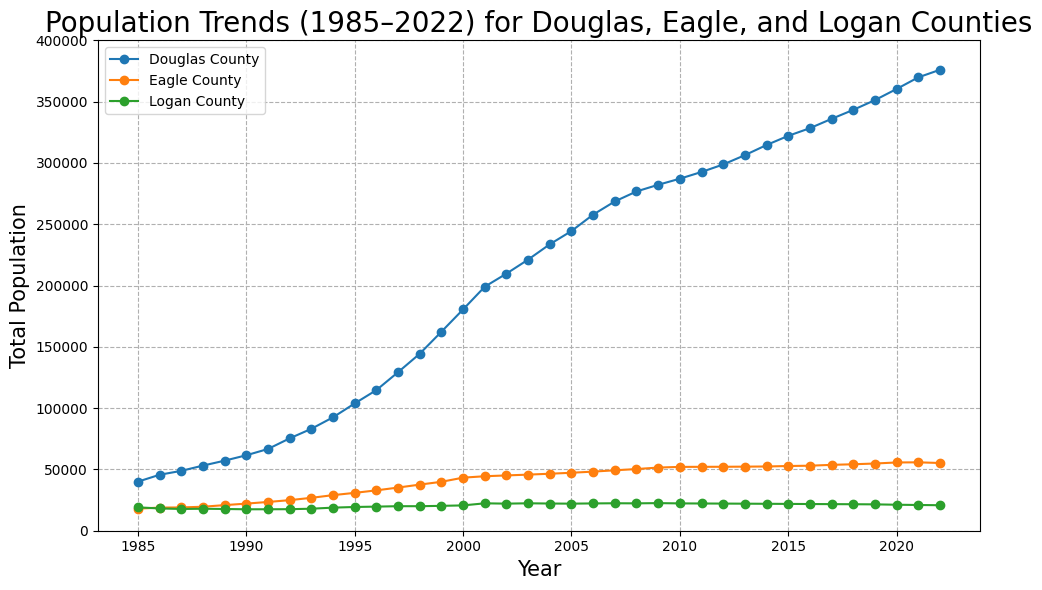

In [ ]:
plt.figure(figsize=(10, 6))

for county in combined_county_pop_df['FULL'].unique():
    county_df = combined_county_pop_df[combined_county_pop_df['FULL'] == county]
    plt.plot(county_df['YEAR'], county_df['TOTAL POPULATION'], marker='o', label=county)

plt.title('Population Trends (1985–2022) for Douglas, Eagle, and Logan Counties', fontsize=20)
plt.xlabel('Year', fontsize=15)
plt.ylabel('Total Population', fontsize=15)
plt.ylim(0, 400000)
plt.yticks(range(0, 400001, 50000))
plt.grid(True, linestyle='--')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Create Plotly figure for the combined county population data
fig_combined_three = px.line(combined_county_pop_df, x='YEAR', y='TOTAL POPULATION', color='FULL',
                       title='Population Trends (1985–2022) for Douglas, Eagle, and Logan Counties')

# Update layout for better readability and add markers
fig_combined_three.update_layout(
    title=dict(
        text='Population Trends (1985–2022) for Douglas, Eagle, and Logan Counties',
        font=dict(size=30)  # Increase title font size
    ),
    yaxis=dict(
        range=[0, 400000],
        tickvals=list(range(0, 400001, 50000)),
        title='Total Population',
        title_font=dict(size=20)  # Increase y-axis label font size
    ),
    xaxis=dict(
        title='Year',
        title_font=dict(size=20)  # Increase x-axis label font size
    ),
    legend_title_text='', # Remove legend title
    font=dict(size=20) # Increase legend font size
)

# Add markers to the lines
fig_combined_three.update_traces(mode='lines+markers')

# Save the combined plot as an HTML file
fig_combined_three.write_html('Douglas Eagle Logan Population Trend.html')